# CGA Path Tracer with Soft Shadows & Precomputed Radiance Transfer

**Extension of the CGA Ray Tracer (Dorst et al. Ch.23) to unbiased Monte Carlo Path Tracing**

This notebook extends the [GA-raytracing](GA-raytracing.ipynb) notebook with:

| Feature | Method |
|---------|--------|
| **Soft shadows** | Area lights (CGA spheres) with multi-sample visibility |
| **Global illumination** | Monte Carlo path tracing with cosine-weighted hemisphere sampling |
| **CGA hemisphere sampling** | CGA rotation rotors to orient samples around surface normal |
| **Russian Roulette** | Unbiased path termination |
| **Precomputed Radiance Transfer** | Spherical Harmonics projection of transfer coefficients |

### Rendering equation
$$L_o(\mathbf{x}, \omega_o) = L_e(\mathbf{x}, \omega_o) + \int_{\Omega} f_r(\mathbf{x}, \omega_i, \omega_o) \, L_i(\mathbf{x}, \omega_i) \, (\omega_i \cdot \mathbf{n}) \, d\omega_i$$

Monte Carlo estimator with $N$ samples and cosine-weighted PDF $p(\omega) = \cos\theta / \pi$:
$$L_o \approx \frac{1}{N} \sum_{k=1}^{N} \frac{f_r \cdot L_i(\omega_k) \cdot \cos\theta_k}{p(\omega_k)} = \frac{1}{N} \sum_{k=1}^{N} \pi \cdot f_r \cdot L_i(\omega_k)$$
since for Lambertian BRDF $f_r = \text{albedo}/\pi$, the estimator simplifies to $\text{albedo} \cdot L_i(\omega_k)$.

In [1]:
# Cell 1 — Imports and CGA algebra setup (same as GA-raytracing)
import numpy as np
import math
from kingdon import Algebra
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Optional, List, Tuple
import time

# ---------- CGA Cl(4,1) ----------
cga = Algebra(4, 1)
e1, e2, e3 = cga.blades['e1'], cga.blades['e2'], cga.blades['e3']
e4, e5 = cga.blades['e4'], cga.blades['e5']
no = 0.5 * (e5 - e4)          # origin
ni = e4 + e5                   # infinity
I5 = e1 * e2 * e3 * e4 * e5   # pseudoscalar, I5^2 = -1
ONE = cga.blades['e']          # scalar unit

print(f'CGA Cl(4,1) ready  |  no·ni = {no | ni}  |  I5² = {I5 * I5}')

CGA Cl(4,1) ready  |  no·ni = -1.0  |  I5² = -1


In [2]:
# Cell 2 — CGA utilities (from GA-raytracing)

def scalar_val(mv):
    items = list(mv.items())
    return float(items[0][1]) if len(items) > 0 and items[0][0] == 0 else 0.0

def get_coeff(mv, blade_name):
    blade = cga.blades[blade_name]
    blade_items = dict(zip(blade.keys(), blade.values()))
    mv_items = dict(zip(mv.keys(), mv.values()))
    for k, v in blade_items.items():
        if k in mv_items:
            return float(mv_items[k]) / float(v)
    return 0.0

def cgaPoint(x, y, z):
    return no + x*e1 + y*e2 + z*e3 + 0.5*(x*x+y*y+z*z)*ni

def cgaPointVec(v):
    return cgaPoint(float(v[0]), float(v[1]), float(v[2]))

def down(P):
    w = scalar_val(-(P | ni))
    if abs(w) < 1e-12: return np.zeros(3)
    return np.array([scalar_val(P|e1)/w, scalar_val(P|e2)/w, scalar_val(P|e3)/w])

def down_flat(fp):
    w = -get_coeff(fp, 'e45')
    if abs(w) < 1e-12: return None
    return np.array([get_coeff(fp,'e14')/w, get_coeff(fp,'e24')/w, get_coeff(fp,'e34')/w])

def cga_dual(X):  return X * (-I5)
def cga_undual(X): return X * I5

# CGA transformations
def translation_rotor(tx, ty, tz):
    t = tx*e1 + ty*e2 + tz*e3
    return ONE - 0.5 * (t ^ ni)

def rotation_rotor(angle, axis_blade):
    return math.cos(angle/2)*ONE - math.sin(angle/2)*axis_blade

def apply_versor(V, X):
    return V * X * ~V

print('CGA utilities ready.')

CGA utilities ready.


In [3]:
# Cell 3 — Scene primitives, materials, geometry (from GA-raytracing + extensions)

@dataclass
class Material:
    color: np.ndarray = field(default_factory=lambda: np.array([0.8, 0.8, 0.8]))
    ambient: float = 0.05
    diffuse: float = 0.8
    specular: float = 0.3
    shininess: float = 32.0
    reflectivity: float = 0.0
    transparency: float = 0.0
    ior: float = 1.5
    emission: np.ndarray = field(default_factory=lambda: np.zeros(3))  # NEW: emissive
    roughness: float = 0.5    # NEW: for glossy BRDF

@dataclass
class Vertex:
    pos: np.ndarray
    pt: object = None
    normal: np.ndarray = None
    tex: np.ndarray = field(default_factory=lambda: np.zeros(2))
    def __post_init__(self):
        self.pt = cgaPointVec(self.pos)
        if self.normal is None:
            self.normal = np.array([0., 1., 0.])

@dataclass
class Face:
    idx: Tuple[int, int, int]
    plane_cga: object = None
    edge_lines: list = field(default_factory=list)
    normal: np.ndarray = None

class Mesh:
    def __init__(self, vertices, faces_idx, color=np.array([0.8,0.8,0.8]),
                 reflectivity=0.0, transparency=0.0, ior=1.0):
        self.vertices = vertices; self.faces = []
        self.color = np.asarray(color, dtype=float)
        self.reflectivity = reflectivity
        self.transparency = transparency; self.ior = ior
        for idx in faces_idx:
            v0, v1, v2 = [self.vertices[i] for i in idx]
            pl = v0.pt ^ v1.pt ^ v2.pt ^ ni
            el = [v0.pt^v1.pt^ni, v1.pt^v2.pt^ni, v2.pt^v0.pt^ni]
            edge1, edge2 = v1.pos-v0.pos, v2.pos-v0.pos
            n = np.cross(edge1, edge2); nn = np.linalg.norm(n)
            if nn > 1e-12: n /= nn
            self.faces.append(Face(idx=idx, plane_cga=pl, edge_lines=el, normal=n))
        pts = np.array([v.pos for v in self.vertices])
        lo, hi = pts.min(0), pts.max(0)
        self.bounding_center = 0.5*(lo+hi)
        self.bounding_radius = np.max(np.linalg.norm(pts - self.bounding_center, axis=1))*1.01

class AnalyticSphere:
    def __init__(self, center, radius, material=None):
        self.center = np.asarray(center, dtype=float)
        self.radius = float(radius)
        self.material = material or Material()
        self.cga_sphere = cgaPointVec(self.center) - 0.5*self.radius**2*ni

class AnalyticPlane:
    def __init__(self, normal, d, material=None):
        self.normal = np.asarray(normal, dtype=float)
        nn = np.linalg.norm(self.normal); self.normal /= nn
        self.d = float(d) / nn
        self.material = material or Material()

class CheckerPlane(AnalyticPlane):
    def __init__(self, normal, d, color1, color2, scale=1.0, **kw):
        super().__init__(normal, d, **kw)
        self.color1 = np.asarray(color1, dtype=float)
        self.color2 = np.asarray(color2, dtype=float)
        self.scale = scale

class AreaLight:
    """Spherical area light — CGA sphere representation.
    Emits light uniformly from the surface of a sphere."""
    def __init__(self, center, radius, color=np.array([1.,1.,1.]), intensity=10.0):
        self.center = np.asarray(center, dtype=float)
        self.radius = float(radius)
        self.color = np.asarray(color, dtype=float)
        self.intensity = float(intensity)
        # CGA: IPNS sphere
        self.cga_sphere = cgaPointVec(self.center) - 0.5*self.radius**2*ni
        # Area for normalization
        self.area = 4.0 * math.pi * self.radius**2
        # Also register as a visible sphere (emissive)
        self.vis_sphere = AnalyticSphere(
            center, radius,
            Material(color=color, emission=color*intensity, diffuse=0.0, specular=0.0)
        )
    
    def sample_point(self):
        """Sample a random point on the sphere surface (uniform)."""
        d = random_unit_sphere()
        return self.center + self.radius * d, d

class PointLight:
    def __init__(self, position, color=np.array([1.,1.,1.]), intensity=1.0):
        self.position = np.asarray(position, dtype=float)
        self.color = np.asarray(color, dtype=float)
        self.intensity = float(intensity)

print('Primitives ready (with AreaLight for soft shadows).')

Primitives ready (with AreaLight for soft shadows).


In [4]:
# Cell 4 — Ray, HitRecord, Camera, intersection routines (from GA-raytracing)

EPSILON = 1e-6

@dataclass
class Ray:
    origin: np.ndarray
    direction: np.ndarray
    def __post_init__(self):
        n = np.linalg.norm(self.direction)
        if n > 1e-12: self.direction = self.direction / n

@dataclass
class HitRecord:
    t: float = float('inf')
    point: np.ndarray = None
    normal: np.ndarray = None
    material: Material = None
    hit: bool = False

class Camera:
    def __init__(self, position, look_at, up=np.array([0.,1.,0.]),
                 fov_deg=60.0, width=320, height=240):
        self.position = np.asarray(position, dtype=float)
        self.look_at = np.asarray(look_at, dtype=float)
        self.width, self.height = width, height
        forward = self.look_at - self.position
        forward /= np.linalg.norm(forward)
        right = np.cross(forward, np.asarray(up, dtype=float))
        right /= np.linalg.norm(right)
        cam_up = np.cross(right, forward)
        self.forward, self.right, self.up = forward, right, cam_up
        self.fov_width = 2.0*math.tan(math.radians(fov_deg)/2.0)
        self.fov_height = self.fov_width * height / width
    def spawn_ray(self, px, py):
        u = (px+0.5)/self.width - 0.5
        v = (py+0.5)/self.height - 0.5
        d = self.forward + u*self.fov_width*self.right + v*self.fov_height*self.up
        return Ray(origin=self.position.copy(), direction=d)

# ---- Intersection routines ----

def intersect_sphere(ray, sphere):
    oc = ray.origin - sphere.center
    b = 2.0*np.dot(oc, ray.direction)
    c = np.dot(oc, oc) - sphere.radius**2
    disc = b*b - 4*c
    if disc < 0: return HitRecord()
    sq = math.sqrt(disc)
    t1, t2 = (-b-sq)/2.0, (-b+sq)/2.0
    t = t1 if t1 > EPSILON else t2
    if t < EPSILON: return HitRecord()
    pt = ray.origin + t*ray.direction
    n = (pt - sphere.center)/sphere.radius
    return HitRecord(t=t, point=pt, normal=n, material=sphere.material, hit=True)

def intersect_plane(ray, plane):
    denom = np.dot(plane.normal, ray.direction)
    if abs(denom) < EPSILON: return HitRecord()
    t = (plane.d - np.dot(plane.normal, ray.origin)) / denom
    if t < EPSILON: return HitRecord()
    pt = ray.origin + t*ray.direction
    n = -plane.normal if denom > 0 else plane.normal.copy()
    mat = Material(color=plane.material.color.copy(), ambient=plane.material.ambient,
                   diffuse=plane.material.diffuse, specular=plane.material.specular,
                   shininess=plane.material.shininess, reflectivity=plane.material.reflectivity,
                   transparency=plane.material.transparency, ior=plane.material.ior,
                   emission=plane.material.emission.copy(), roughness=plane.material.roughness)
    if isinstance(plane, CheckerPlane):
        x, z = pt[0]/plane.scale, pt[2]/plane.scale
        mat.color = plane.color1.copy() if (int(math.floor(x))+int(math.floor(z)))%2==0 else plane.color2.copy()
    return HitRecord(t=t, point=pt, normal=n, material=mat, hit=True)

def intersect_triangle(ray, v0, v1, v2):
    edge1, edge2 = v1-v0, v2-v0
    h = np.cross(ray.direction, edge2); a = np.dot(edge1, h)
    if -EPSILON < a < EPSILON: return None
    f = 1.0/a; s = ray.origin - v0; u = f*np.dot(s, h)
    if u < 0 or u > 1: return None
    q = np.cross(s, edge1); v = f*np.dot(ray.direction, q)
    if v < 0 or u+v > 1: return None
    t = f*np.dot(edge2, q)
    return (t, u, v) if t > EPSILON else None

def intersect_mesh(ray, mesh):
    oc = ray.origin - mesh.bounding_center
    b = 2.0*np.dot(oc, ray.direction)
    c = np.dot(oc, oc) - mesh.bounding_radius**2
    if b*b-4*c < 0: return HitRecord()
    best = HitRecord()
    for face in mesh.faces:
        v0, v1, v2 = [mesh.vertices[i].pos for i in face.idx]
        r = intersect_triangle(ray, v0, v1, v2)
        if r and r[0] < best.t:
            t, u, v = r; pt = ray.origin + t*ray.direction; w = 1-u-v
            ni_ = sum(c*mesh.vertices[i].normal for c, i in zip([w,u,v], face.idx))
            nn = np.linalg.norm(ni_)
            if nn > 1e-12: ni_ /= nn
            mat = Material(color=mesh.color, reflectivity=mesh.reflectivity,
                           transparency=mesh.transparency, ior=mesh.ior)
            best = HitRecord(t=t, point=pt, normal=ni_, material=mat, hit=True)
    return best

def reflect_direction(d, n):
    return d - 2.0*np.dot(d, n)*n

def refract_direction(d, n, eta):
    cos_i = -np.dot(n, d)
    sin2_t = eta*eta*(1.0-cos_i*cos_i)
    if sin2_t > 1.0: return None
    return eta*d + (eta*cos_i - math.sqrt(1.0-sin2_t))*n

print('Intersection routines ready.')

Intersection routines ready.


## Hemisphere Sampling with CGA Rotors

For path tracing we need to sample random directions in the hemisphere above a surface point.
We use **cosine-weighted** sampling: $p(\omega) = \cos\theta / \pi$, which importance-samples the
Lambertian BRDF and eliminates the $\cos\theta$ term from the estimator.

The CGA approach: generate a direction in the canonical hemisphere (around $+y$), then
apply a **CGA rotation rotor** to align it with the actual surface normal $\mathbf{n}$.

$$R = \cos(\theta/2) - \sin(\theta/2) \, B_{\mathbf{e}_2, \mathbf{n}}$$

where $B$ is the bivector of the rotation plane from $\mathbf{e}_2$ to $\mathbf{n}$.

In [5]:
# Cell 5 — Hemisphere sampling with CGA rotors

def random_unit_sphere():
    """Uniformly random direction on the unit sphere."""
    while True:
        v = np.random.randn(3)
        n = np.linalg.norm(v)
        if n > 1e-8:
            return v / n


def cosine_weighted_hemisphere():
    """Sample direction in hemisphere around +Y using cosine-weighted distribution.
    Returns (direction, pdf).  PDF = cos(theta) / pi."""
    u1, u2 = np.random.rand(), np.random.rand()
    r = math.sqrt(u1)
    theta = 2.0 * math.pi * u2
    x = r * math.cos(theta)
    z = r * math.sin(theta)
    y = math.sqrt(max(0.0, 1.0 - u1))  # cos(elevation)
    return np.array([x, y, z])


def orient_hemisphere_cga(local_dir, normal):
    """Rotate local_dir (in Y-up hemisphere) to align with surface normal
    using a CGA rotation rotor.
    
    Builds the rotor R that takes e2 -> normal, then applies R to local_dir.
    """
    up = np.array([0., 1., 0.])
    dot = np.dot(up, normal)
    
    if dot > 0.9999:
        return local_dir   # already aligned
    if dot < -0.9999:
        return -local_dir  # opposite hemisphere
    
    # Bivector of the rotation plane: up ^ normal
    # In CGA, we use the Euclidean bivector part for pure rotations
    biv = (up[0]*e1 + up[1]*e2 + up[2]*e3) ^ (normal[0]*e1 + normal[1]*e2 + normal[2]*e3)
    
    # Angle between up and normal
    angle = math.acos(np.clip(dot, -1.0, 1.0))
    
    # Normalize the bivector
    biv_sq = scalar_val(biv * biv)
    if abs(biv_sq) < 1e-12:
        return local_dir
    biv_norm = biv * (1.0 / math.sqrt(abs(biv_sq)))
    
    # Build CGA rotation rotor: R = cos(a/2) - sin(a/2)*B
    R = math.cos(angle/2)*ONE - math.sin(angle/2)*biv_norm
    
    # Apply rotor to the local direction (as a CGA free vector)
    d_cga = local_dir[0]*e1 + local_dir[1]*e2 + local_dir[2]*e3
    d_rot = R * d_cga * ~R
    
    # Extract Euclidean components
    rx = scalar_val(d_rot | e1)
    ry = scalar_val(d_rot | e2)
    rz = scalar_val(d_rot | e3)
    result = np.array([rx, ry, rz])
    n = np.linalg.norm(result)
    return result / n if n > 1e-12 else normal


def orient_hemisphere_fast(local_dir, normal):
    """Fast tangent-space to world-space using orthonormal basis (fallback)."""
    if abs(normal[0]) > 0.9:
        tangent = np.cross(np.array([0., 1., 0.]), normal)
    else:
        tangent = np.cross(np.array([1., 0., 0.]), normal)
    tangent /= np.linalg.norm(tangent)
    bitangent = np.cross(normal, tangent)
    return local_dir[0]*tangent + local_dir[1]*normal + local_dir[2]*bitangent


# --- Validate CGA hemisphere sampling ---
normal_test = np.array([0., 0., 1.])  # z-up
dirs_cga = [orient_hemisphere_cga(cosine_weighted_hemisphere(), normal_test) for _ in range(1000)]
dirs_fast = [orient_hemisphere_fast(cosine_weighted_hemisphere(), normal_test) for _ in range(1000)]

# All sampled directions should be in the z-up hemisphere
cga_above = np.mean([d[2] > 0 for d in dirs_cga])
fast_above = np.mean([d[2] > 0 for d in dirs_fast])
print(f'CGA hemisphere: {cga_above*100:.0f}% above normal  |  '
      f'Fast hemisphere: {fast_above*100:.0f}% above normal')
print(f'CGA mean direction: {np.round(np.mean(dirs_cga, axis=0), 3)}')

CGA hemisphere: 100% above normal  |  Fast hemisphere: 100% above normal
CGA mean direction: [-0.005  0.001  0.669]


## Path Tracing Integrator

The path tracer replaces the ray tracer's direct-illumination `shade()` function with
a recursive Monte Carlo estimator that follows random bounces through the scene.

### Key differences from the Dorst ray tracer:
1. **No explicit shadow rays** — shadows emerge naturally from random sampling
2. **Area lights** — visible emissive spheres produce soft shadows
3. **Next Event Estimation (NEE)** — at each bounce, we explicitly sample the light *and* do a random bounce, then combine with MIS weights
4. **Russian Roulette** — unbiased path termination after a few bounces

In [6]:
# Cell 6 — Scene class and Path Tracing integrator

class PTScene:
    """Scene for path tracing — supports area lights and emissive materials."""
    def __init__(self):
        self.spheres: List[AnalyticSphere] = []
        self.planes: List[AnalyticPlane] = []
        self.meshes: List[Mesh] = []
        self.area_lights: List[AreaLight] = []
        self.point_lights: List[PointLight] = []  # for hybrid mode
        self.bg_color = np.array([0.05, 0.05, 0.1])  # dark sky
        self.sky_intensity = 0.2
    
    def closest_hit(self, ray: Ray) -> HitRecord:
        best = HitRecord()
        for sp in self.spheres:
            h = intersect_sphere(ray, sp)
            if h.hit and h.t < best.t: best = h
        # Area light spheres are also intersectable
        for al in self.area_lights:
            h = intersect_sphere(ray, al.vis_sphere)
            if h.hit and h.t < best.t: best = h
        for pl in self.planes:
            h = intersect_plane(ray, pl)
            if h.hit and h.t < best.t: best = h
        for ms in self.meshes:
            h = intersect_mesh(ray, ms)
            if h.hit and h.t < best.t: best = h
        return best
    
    def any_hit(self, ray: Ray, max_t: float) -> bool:
        """Fast shadow test — returns True if anything blocks before max_t."""
        for sp in self.spheres:
            h = intersect_sphere(ray, sp)
            if h.hit and h.t < max_t: return True
        for pl in self.planes:
            h = intersect_plane(ray, pl)
            if h.hit and h.t < max_t: return True
        for ms in self.meshes:
            h = intersect_mesh(ray, ms)
            if h.hit and h.t < max_t: return True
        return False


def sample_area_light_direct(scene, hit_point, hit_normal, light):
    """Next Event Estimation: sample a point on the area light, test visibility.
    Returns (radiance_contribution, was_visible)."""
    light_pos, light_normal = light.sample_point()
    to_light = light_pos - hit_point
    dist = np.linalg.norm(to_light)
    if dist < EPSILON:
        return np.zeros(3), False
    light_dir = to_light / dist
    
    # Geometry term
    cos_surface = np.dot(hit_normal, light_dir)
    cos_light = abs(np.dot(-light_dir, light_normal))  # light facing us
    if cos_surface <= 0:
        return np.zeros(3), False
    
    # Visibility test (shadow ray)
    shadow_ray = Ray(origin=hit_point + EPSILON*light_dir, direction=light_dir)
    if scene.any_hit(shadow_ray, dist - 2*EPSILON):
        return np.zeros(3), False
    
    # Solid angle PDF and radiance
    # PDF_area = 1 / area,  convert to solid angle: PDF_sa = PDF_area * dist^2 / cos_light
    pdf_sa = (dist * dist) / (cos_light * light.area) if cos_light > EPSILON else 1e10
    emission = light.color * light.intensity
    
    # Contribution: L * BRDF * cos_theta / pdf
    # For Lambertian: BRDF = albedo/pi, so contribution = emission * cos_surface / (pi * pdf_sa)
    # Simplified: emission * cos_surface * cos_light * area / (pi * dist^2)
    return emission * cos_surface / (math.pi * pdf_sa), True


def path_trace(scene: PTScene, ray: Ray, max_depth: int = 8) -> np.ndarray:
    """Unbiased Monte Carlo path tracer with Russian Roulette."""
    color = np.zeros(3)
    throughput = np.ones(3)   # accumulated BRDF attenuation
    current_ray = ray
    
    for bounce in range(max_depth):
        hit = scene.closest_hit(current_ray)
        if not hit.hit:
            # Sky contribution
            color += throughput * scene.bg_color * scene.sky_intensity
            break
        
        mat = hit.material
        
        # --- Emission (area lights glow) ---
        emission = mat.emission
        if np.any(emission > 0):
            color += throughput * emission
            break  # light source terminates the path
        
        # --- Next Event Estimation: explicitly sample area lights ---
        for light in scene.area_lights:
            direct, visible = sample_area_light_direct(scene, hit.point, hit.normal, light)
            if visible:
                color += throughput * mat.color * direct
        
        # --- Also sample point lights (hybrid) ---
        for pl in scene.point_lights:
            to_l = pl.position - hit.point
            dist_l = np.linalg.norm(to_l); l_dir = to_l / dist_l
            cos_s = np.dot(hit.normal, l_dir)
            if cos_s > 0:
                sr = Ray(origin=hit.point + EPSILON*l_dir, direction=l_dir)
                if not scene.any_hit(sr, dist_l - 2*EPSILON):
                    color += throughput * mat.diffuse * cos_s * mat.color * pl.color * pl.intensity
        
        # --- Russian Roulette (after first 3 bounces) ---
        if bounce >= 3:
            survival = min(0.95, np.max(throughput))
            if np.random.rand() > survival:
                break
            throughput /= survival
        
        # --- Sample next bounce direction ---
        if mat.reflectivity > 0.5:
            # Mirror reflection
            new_dir = reflect_direction(current_ray.direction, hit.normal)
            throughput *= mat.color
        elif mat.transparency > 0.5:
            # Refraction with Fresnel approximation
            cos_i = np.dot(-current_ray.direction, hit.normal)
            if cos_i < 0:
                n_refr, eta = -hit.normal, mat.ior
            else:
                n_refr, eta = hit.normal, 1.0/mat.ior
            refr = refract_direction(current_ray.direction, n_refr, eta)
            if refr is not None:
                new_dir = refr
                throughput *= mat.color
            else:
                new_dir = reflect_direction(current_ray.direction, hit.normal)
                throughput *= mat.color
        else:
            # Diffuse bounce — cosine-weighted hemisphere sampling
            local_dir = cosine_weighted_hemisphere()
            new_dir = orient_hemisphere_fast(local_dir, hit.normal)
            # For cosine-weighted sampling of Lambertian BRDF:
            # throughput *= albedo  (the pi's cancel)
            throughput *= mat.color
        
        current_ray = Ray(origin=hit.point + EPSILON*new_dir, direction=new_dir)
    
    return np.clip(color, 0.0, 50.0)  # soft clamp for fireflies


print('Path tracing integrator ready.')

Path tracing integrator ready.


In [7]:
# Cell 7 — Path tracing renderer with progressive display

def render_pt(scene: PTScene, camera: Camera, spp=16, max_depth=6):
    """Render using Monte Carlo path tracing."""
    W, H = camera.width, camera.height
    image = np.zeros((H, W, 3))
    t0 = time.time()
    
    for y in range(H):
        for x in range(W):
            color = np.zeros(3)
            for s in range(spp):
                dx = np.random.rand() - 0.5
                dy = np.random.rand() - 0.5
                ray = camera.spawn_ray(x + dx, y + dy)
                color += path_trace(scene, ray, max_depth)
            image[H-1-y, x] = color / spp
        
        if (y+1) % max(1, H//10) == 0:
            print(f'  {100*(y+1)/H:5.1f}% ({time.time()-t0:.1f}s)', end='\r')
    
    print(f'  Path trace done: {W}x{H}, {spp} spp, {time.time()-t0:.1f}s          ')
    return image


def tonemap_aces(img):
    """ACES filmic tonemapping for HDR path traced output."""
    a, b, c, d, e_ = 2.51, 0.03, 2.43, 0.59, 0.14
    x = img
    return np.clip((x*(a*x+b)) / (x*(c*x+d)+e_), 0.0, 1.0)


print('Renderer ready.')

Renderer ready.


## Build Path Tracing Scene

We create a scene with **area lights** (CGA spheres) to demonstrate:
- **Soft shadows** from extended light sources
- **Color bleeding** from indirect illumination
- **Glossy reflections** and **caustics** through glass

In [8]:
# Cell 8 — Build path tracing scene

pt_scene = PTScene()
pt_scene.bg_color = np.array([0.4, 0.6, 0.9])  # sky blue
pt_scene.sky_intensity = 0.3

# Ground plane
pt_scene.planes.append(CheckerPlane(
    normal=[0,1,0], d=-1.0,
    color1=np.array([0.85, 0.85, 0.85]),
    color2=np.array([0.25, 0.25, 0.25]),
    scale=2.0,
    material=Material(color=np.array([0.5,0.5,0.5]),
                      ambient=0.0, diffuse=0.8, specular=0.1,
                      reflectivity=0.15, roughness=0.8)
))

# Reflective sphere (left)
pt_scene.spheres.append(AnalyticSphere(
    center=[-2.0, 0.5, 4.0], radius=1.5,
    material=Material(color=np.array([0.9, 0.9, 0.95]),
                      reflectivity=0.85, roughness=0.05)
))

# Glass sphere (center-right)
pt_scene.spheres.append(AnalyticSphere(
    center=[2.0, 0.0, 5.0], radius=1.0,
    material=Material(color=np.array([0.98, 0.98, 1.0]),
                      transparency=0.9, ior=1.5, reflectivity=0.1)
))

# Matte red sphere
pt_scene.spheres.append(AnalyticSphere(
    center=[4.5, -0.2, 7.0], radius=0.8,
    material=Material(color=np.array([0.9, 0.15, 0.1]), diffuse=0.9)
))

# Golden sphere
pt_scene.spheres.append(AnalyticSphere(
    center=[0.0, -0.5, 3.0], radius=0.5,
    material=Material(color=np.array([0.9, 0.7, 0.2]),
                      reflectivity=0.4, roughness=0.2)
))

# Box mesh
def make_box(cx, cy, cz, sx, sy, sz, color, reflectivity=0.0):
    corners = [np.array([cx+dx, cy+dy, cz+dz])
               for dx in [-sx,sx] for dy in [-sy,sy] for dz in [-sz,sz]]
    verts, faces = [], []
    for cidx, n in [([0,4,6,2],[0,-1,0]),([1,3,7,5],[0,1,0]),
                    ([0,1,5,4],[0,0,-1]),([2,6,7,3],[0,0,1]),
                    ([0,2,3,1],[-1,0,0]),([4,5,7,6],[1,0,0])]:
        n = np.array(n, dtype=float)
        vi = len(verts)
        for i in cidx:
            verts.append(Vertex(pos=corners[i].copy(), normal=n.copy()))
        faces += [(vi,vi+1,vi+2), (vi,vi+2,vi+3)]
    return Mesh(verts, faces, color=color, reflectivity=reflectivity)

pt_scene.meshes.append(make_box(-4.0, 0.0, 7.0, 0.8, 1.0, 0.8,
    color=np.array([0.3, 0.6, 0.9]), reflectivity=0.1))

# --- Area Lights (CGA spheres for soft shadows) ---
pt_scene.area_lights.append(AreaLight(
    center=np.array([-4., 6., 0.]),
    radius=1.5,
    color=np.array([1.0, 0.95, 0.85]),
    intensity=8.0
))
pt_scene.area_lights.append(AreaLight(
    center=np.array([6., 5., 2.]),
    radius=1.0,
    color=np.array([0.85, 0.9, 1.0]),
    intensity=6.0
))

print(f'PT Scene: {len(pt_scene.spheres)} spheres, {len(pt_scene.planes)} planes, '
      f'{len(pt_scene.meshes)} meshes, {len(pt_scene.area_lights)} area lights')

PT Scene: 4 spheres, 1 planes, 1 meshes, 2 area lights


  Path trace done: 160x120, 16 spp, 44.7s          


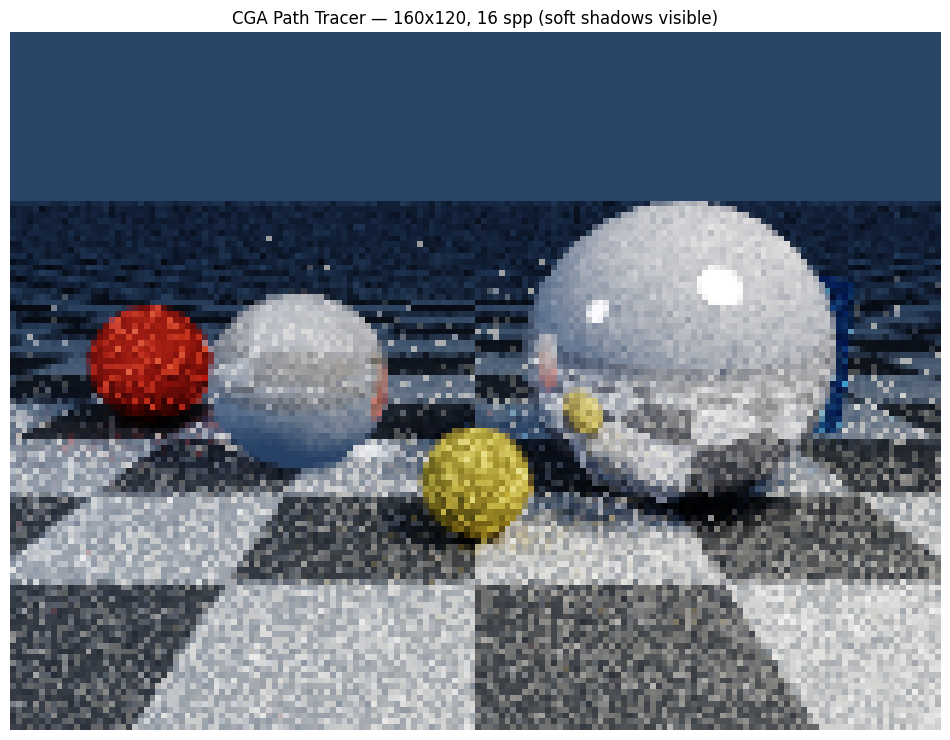

In [9]:
# Cell 9 — Low resolution path trace (quick validation)

cam_pt = Camera(position=np.array([0., 2., -4.]),
                look_at=np.array([0., 0., 5.]),
                fov_deg=60, width=160, height=120)

img_pt_low = render_pt(pt_scene, cam_pt, spp=16, max_depth=5)
img_pt_low_tm = tonemap_aces(img_pt_low)

plt.figure(figsize=(10, 7.5))
plt.imshow(img_pt_low_tm)
plt.axis('off')
plt.title('CGA Path Tracer — 160x120, 16 spp (soft shadows visible)')
plt.tight_layout()
plt.show()

  Path trace done: 320x240, 32 spp, 356.7s          


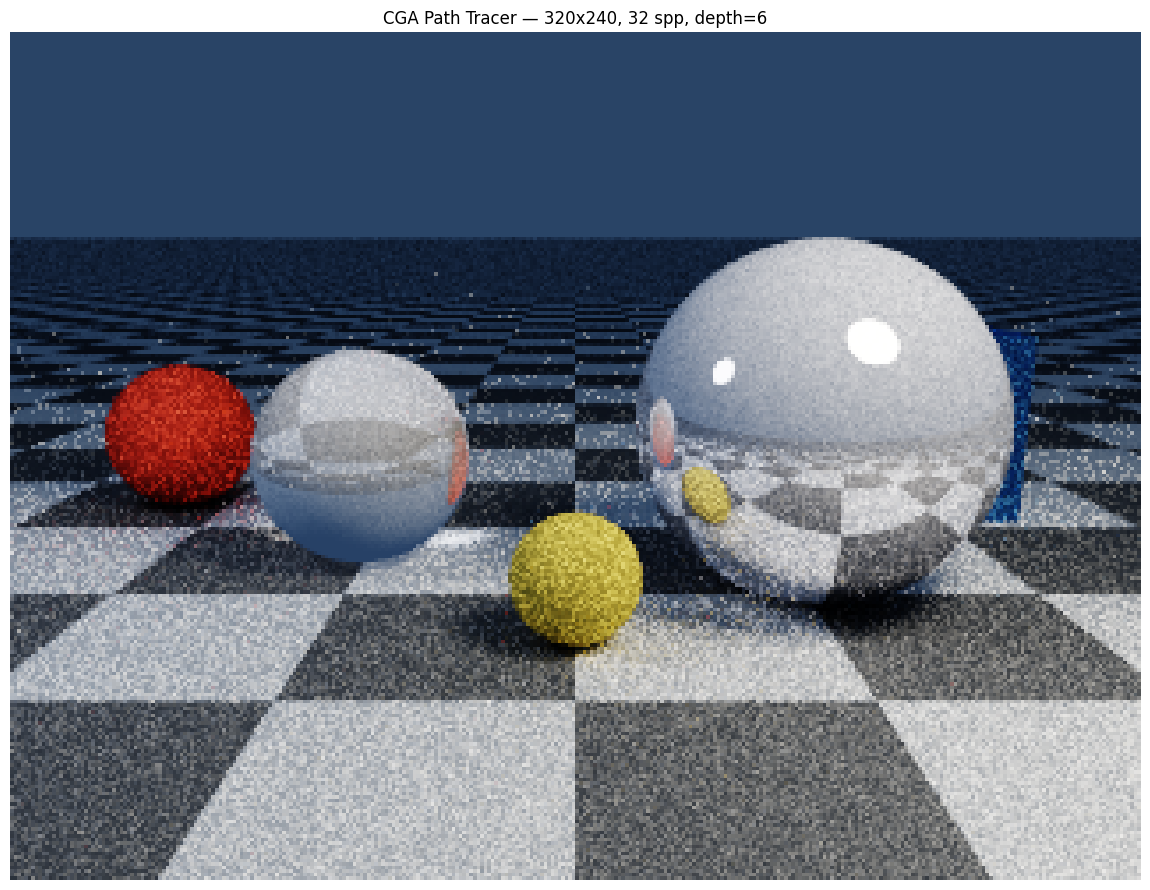

In [10]:
# Cell 10 — Medium resolution path trace

cam_pt_med = Camera(position=np.array([0., 2., -4.]),
                    look_at=np.array([0., 0., 5.]),
                    fov_deg=60, width=320, height=240)

img_pt_med = render_pt(pt_scene, cam_pt_med, spp=32, max_depth=6)
img_pt_med_tm = tonemap_aces(img_pt_med)

plt.figure(figsize=(12, 9))
plt.imshow(img_pt_med_tm)
plt.axis('off')
plt.title('CGA Path Tracer — 320x240, 32 spp, depth=6')
plt.tight_layout()
plt.show()

## Precomputed Radiance Transfer (PRT)

PRT precomputes how each surface point responds to distant lighting, encoded in **Spherical Harmonics (SH)**.

### Overview
1. **SH Basis**: $Y_l^m(\theta, \phi)$ — orthonormal functions on the sphere, up to order $l_{\max}$.
2. **Environment map projection**: $L_{lm} = \int_{S^2} L(\omega) \, Y_l^m(\omega) \, d\omega$
3. **Transfer coefficients**: At each surface point, Monte Carlo estimate:
   $$T_{lm}(\mathbf{x}) = \frac{1}{N}\sum_{k} V(\mathbf{x}, \omega_k) \, (\omega_k \cdot \mathbf{n}) \, Y_l^m(\omega_k) \cdot \frac{4\pi}{p(\omega_k)}$$
   where $V$ = visibility, $p$ = sampling PDF.
4. **Relighting** (real-time dot product): $L_o(\mathbf{x}) = \text{albedo} \sum_{lm} L_{lm} \, T_{lm}(\mathbf{x})$

For diffuse PRT we only need the *unshadowed* and *shadowed* transfer; the SH order controls softness.

In [11]:
# Cell 11 — Spherical Harmonics basis functions (real, up to order 2)

def sh_basis(direction, max_order=2):
    """Evaluate real spherical harmonics up to order max_order at a given direction.
    Returns array of (max_order+1)^2 coefficients.
    
    Order 0 (1 coeff):  Y_00
    Order 1 (3 coeffs): Y_1{-1}, Y_10, Y_11
    Order 2 (5 coeffs): Y_2{-2}, Y_2{-1}, Y_20, Y_21, Y_22
    """
    x, y, z = direction[0], direction[1], direction[2]
    
    coeffs = []
    
    # Band 0 (1 coefficient)
    coeffs.append(0.282095)  # Y_00 = 0.5 * sqrt(1/pi)
    
    if max_order >= 1:
        # Band 1 (3 coefficients)
        coeffs.append(0.488603 * y)   # Y_1,-1
        coeffs.append(0.488603 * z)   # Y_1,0
        coeffs.append(0.488603 * x)   # Y_1,1
    
    if max_order >= 2:
        # Band 2 (5 coefficients)
        coeffs.append(1.092548 * x * y)                  # Y_2,-2
        coeffs.append(1.092548 * y * z)                  # Y_2,-1
        coeffs.append(0.315392 * (3*z*z - 1))            # Y_2,0
        coeffs.append(1.092548 * x * z)                  # Y_2,1
        coeffs.append(0.546274 * (x*x - y*y))            # Y_2,2
    
    return np.array(coeffs)


def sh_num_coeffs(max_order):
    return (max_order + 1) ** 2


# --- Test: SH orthonormality ---
N_test = 10000
test_dirs = np.array([random_unit_sphere() for _ in range(N_test)])
test_sh = np.array([sh_basis(d, max_order=2) for d in test_dirs])

# Monte Carlo integral of Y_i * Y_j over sphere should be delta_ij * 4*pi
# (since we sample uniformly, weight = 4*pi/N)
gram = (4.0 * math.pi / N_test) * test_sh.T @ test_sh
print('SH Gram matrix diagonal (should be ~1.0):', np.round(np.diag(gram), 3))
print(f'SH coefficients: {sh_num_coeffs(2)} for order 2')

SH Gram matrix diagonal (should be ~1.0): [1.    1.008 0.991 1.001 0.992 0.988 1.    0.997 1.023]
SH coefficients: 9 for order 2


In [12]:
# Cell 12 — PRT: Environment map projection and transfer coefficient computation

def project_environment_sh(env_func, max_order=2, n_samples=5000):
    """Project an environment lighting function into SH coefficients.
    env_func(direction) -> RGB color.
    Returns array of shape (n_coeffs, 3)."""
    n_coeffs = sh_num_coeffs(max_order)
    result = np.zeros((n_coeffs, 3))
    
    for _ in range(n_samples):
        d = random_unit_sphere()
        L = env_func(d)              # RGB
        Y = sh_basis(d, max_order)   # SH coefficients
        result += np.outer(Y, L)     # accumulate
    
    # Monte Carlo: integral = (4*pi / N) * sum
    result *= 4.0 * math.pi / n_samples
    return result


def compute_transfer_sh(scene, point, normal, max_order=2, n_samples=256):
    """Compute PRT transfer coefficients at a surface point.
    T_lm = (4*pi / N) * sum_k V(x, w_k) * max(0, w_k . n) * Y_lm(w_k)
    Uses cosine-weighted hemisphere sampling."""
    n_coeffs = sh_num_coeffs(max_order)
    transfer = np.zeros(n_coeffs)
    
    for _ in range(n_samples):
        # Cosine-weighted sample on hemisphere
        local = cosine_weighted_hemisphere()
        w = orient_hemisphere_fast(local, normal)
        
        cos_theta = np.dot(w, normal)
        if cos_theta <= 0:
            continue
        
        # Visibility test
        vis_ray = Ray(origin=point + EPSILON * w, direction=w)
        blocked = scene.any_hit(vis_ray, 1000.0)
        V = 0.0 if blocked else 1.0
        
        # SH basis at this direction
        Y = sh_basis(w, max_order)
        
        # For cosine-weighted sampling, PDF = cos_theta / pi
        # Transfer = V * cos_theta * Y / PDF = V * pi * Y
        transfer += V * math.pi * Y
    
    transfer /= n_samples
    return transfer


def prt_shade(transfer_coeffs, env_sh_coeffs, albedo):
    """Shade a point using precomputed transfer and environment SH.
    L_out = albedo * sum_lm (L_lm * T_lm) for each color channel."""
    # transfer_coeffs: (n_coeffs,)
    # env_sh_coeffs: (n_coeffs, 3)
    color = np.zeros(3)
    for ch in range(3):
        color[ch] = np.dot(transfer_coeffs, env_sh_coeffs[:, ch])
    return albedo * np.clip(color, 0, None)


# --- Define some environment maps ---

def env_overhead_warm(d):
    """Warm overhead light (like a sun high in sky)."""
    sun_dir = np.array([0.3, 0.9, 0.1])
    sun_dir /= np.linalg.norm(sun_dir)
    sun = max(0, np.dot(d, sun_dir)) ** 20 * 5.0
    sky = max(0, d[1]) * 0.4
    return np.array([1.0, 0.9, 0.7]) * sun + np.array([0.3, 0.5, 0.9]) * sky


def env_sunset(d):
    """Sunset: low warm sun + blue sky above + dark below."""
    sun_dir = np.array([-0.8, 0.2, 0.3])
    sun_dir /= np.linalg.norm(sun_dir)
    sun = max(0, np.dot(d, sun_dir)) ** 30 * 8.0
    sky = max(0, d[1]) * 0.2
    horizon = max(0, 1.0 - abs(d[1])) ** 3 * 0.5
    return (np.array([1.0, 0.6, 0.2]) * sun +
            np.array([0.2, 0.3, 0.7]) * sky +
            np.array([0.8, 0.4, 0.2]) * horizon)


def env_cool_blue(d):
    """Cool blue environment (overcast)."""
    sky = max(0, d[1]) * 0.6 + 0.15
    return np.array([0.4, 0.5, 0.8]) * sky


# Project environments into SH
print('Projecting environment maps into SH...')
env_warm_sh = project_environment_sh(env_overhead_warm, max_order=2, n_samples=10000)
env_sunset_sh = project_environment_sh(env_sunset, max_order=2, n_samples=10000)
env_cool_sh = project_environment_sh(env_cool_blue, max_order=2, n_samples=10000)
print(f'Environment SH coefficients shape: {env_warm_sh.shape}')
print('Done.')

Projecting environment maps into SH...
Environment SH coefficients shape: (9, 3)
Done.


In [13]:
# Cell 13 — PRT rendering: precompute transfer then relight

def render_prt(scene: PTScene, camera: Camera, env_sh, max_order=2,
               transfer_samples=128):
    """Render using Precomputed Radiance Transfer.
    For each visible point: compute transfer SH, dot with env SH."""
    W, H = camera.width, camera.height
    image = np.zeros((H, W, 3))
    t0 = time.time()
    
    for y in range(H):
        for x in range(W):
            ray = camera.spawn_ray(x, y)
            hit = scene.closest_hit(ray)
            
            if not hit.hit:
                # Sky: evaluate environment directly from ray direction
                Y = sh_basis(ray.direction, max_order)
                for ch in range(3):
                    image[H-1-y, x, ch] = np.dot(Y, env_sh[:, ch])
                continue
            
            mat = hit.material
            if np.any(mat.emission > 0):
                image[H-1-y, x] = mat.emission
                continue
            
            # Get albedo (handle checkerboard)
            albedo = mat.color
            
            # Compute transfer at this point
            transfer = compute_transfer_sh(scene, hit.point, hit.normal,
                                          max_order=max_order,
                                          n_samples=transfer_samples)
            
            # Shade using PRT dot product
            color = prt_shade(transfer, env_sh, albedo)
            
            # Add specular reflection approximation
            if mat.reflectivity > 0.2:
                refl_dir = reflect_direction(ray.direction, hit.normal)
                Y_refl = sh_basis(refl_dir, max_order)
                refl_color = np.zeros(3)
                for ch in range(3):
                    refl_color[ch] = np.dot(Y_refl, env_sh[:, ch])
                color = (1-mat.reflectivity)*color + mat.reflectivity*np.clip(refl_color, 0, None)
            
            image[H-1-y, x] = color
        
        if (y+1) % max(1, H//10) == 0:
            print(f'  {100*(y+1)/H:5.1f}% ({time.time()-t0:.1f}s)', end='\r')
    
    print(f'  PRT render done: {W}x{H}, {time.time()-t0:.1f}s            ')
    return image

print('PRT renderer ready.')

PRT renderer ready.


Rendering PRT with 3 environment maps...
  PRT render done: 160x120, 37.9s            
  PRT render done: 160x120, 38.2s            
  PRT render done: 160x120, 38.3s            
Total PRT time: 114.4s


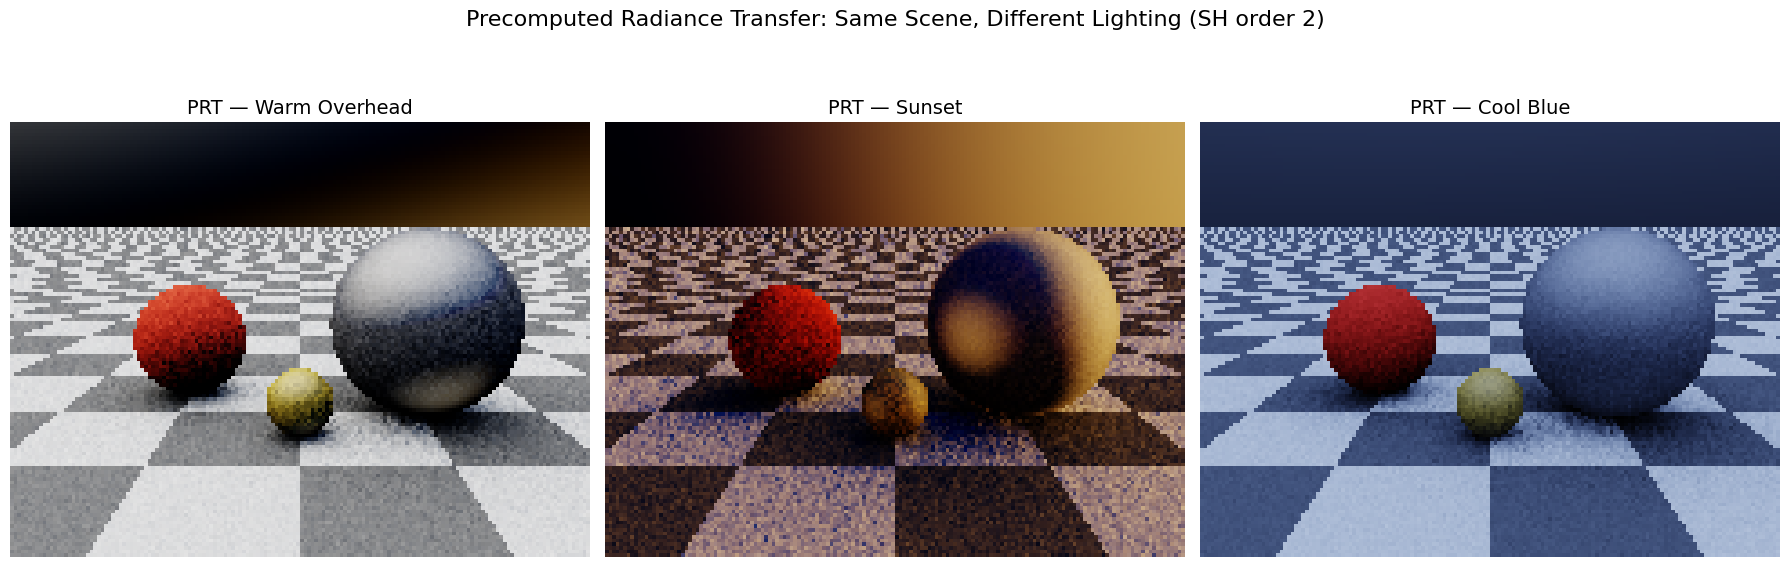

In [14]:
# Cell 14 — PRT demo: render same scene under 3 different environment maps

cam_prt = Camera(position=np.array([0., 2., -4.]),
                 look_at=np.array([0., 0., 5.]),
                 fov_deg=60, width=160, height=120)

# Build a simpler scene for PRT (no area light spheres blocking)
prt_scene = PTScene()
prt_scene.bg_color = np.array([0.4, 0.6, 0.9])
prt_scene.sky_intensity = 0.3

prt_scene.planes.append(CheckerPlane(
    normal=[0,1,0], d=-1.0,
    color1=np.array([0.85,0.85,0.85]),
    color2=np.array([0.25,0.25,0.25]),
    scale=2.0,
    material=Material(color=np.array([0.5,0.5,0.5]), diffuse=0.8, reflectivity=0.1)
))
prt_scene.spheres.append(AnalyticSphere(
    [-2.0, 0.5, 4.0], 1.5,
    Material(color=np.array([0.9,0.9,0.95]), reflectivity=0.7)
))
prt_scene.spheres.append(AnalyticSphere(
    [2.0, 0.0, 5.0], 1.0,
    Material(color=np.array([0.9,0.15,0.1]), diffuse=0.9)
))
prt_scene.spheres.append(AnalyticSphere(
    [0.0, -0.5, 3.0], 0.5,
    Material(color=np.array([0.9,0.7,0.2]), diffuse=0.7, reflectivity=0.3)
))

print('Rendering PRT with 3 environment maps...')
t0 = time.time()

img_prt_warm = render_prt(prt_scene, cam_prt, env_warm_sh, transfer_samples=64)
img_prt_sunset = render_prt(prt_scene, cam_prt, env_sunset_sh, transfer_samples=64)
img_prt_cool = render_prt(prt_scene, cam_prt, env_cool_sh, transfer_samples=64)

print(f'Total PRT time: {time.time()-t0:.1f}s')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, img, title in zip(axes,
    [img_prt_warm, img_prt_sunset, img_prt_cool],
    ['Warm Overhead', 'Sunset', 'Cool Blue']):
    ax.imshow(tonemap_aces(img))
    ax.set_title(f'PRT — {title}', fontsize=14)
    ax.axis('off')
plt.suptitle('Precomputed Radiance Transfer: Same Scene, Different Lighting (SH order 2)',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Comparison: Ray Tracing vs Path Tracing vs PRT

We render the same scene with all three methods at the same resolution for direct comparison.

Rendering comparison...
  RT done: 11.2s          
  Path trace done: 320x240, 32 spp, 357.6s          
  PRT render done: 320x240, 150.8s            


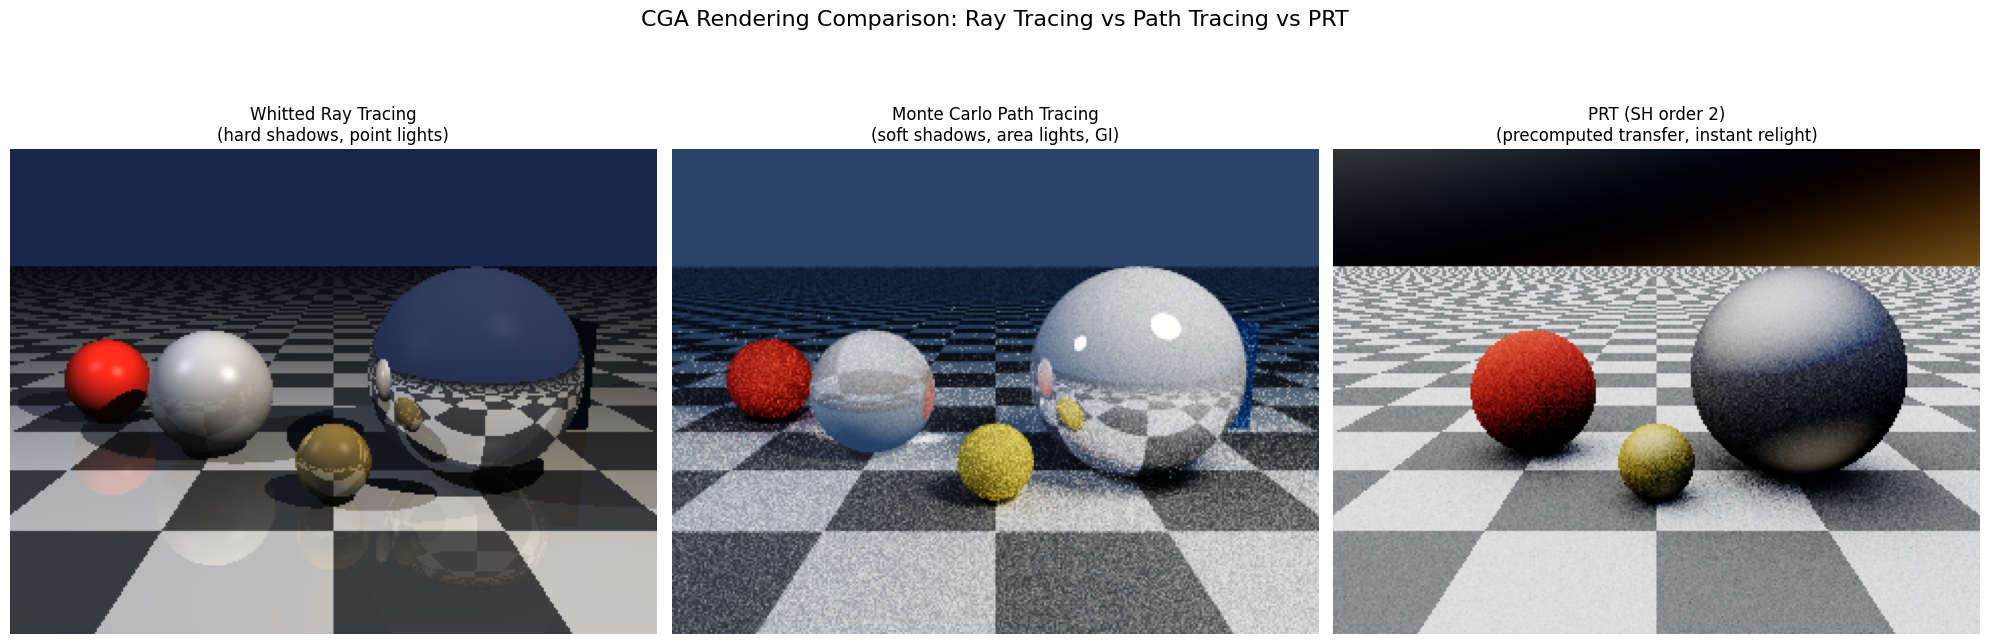

In [15]:
# Cell 15 — Side-by-side comparison at 320x240

cam_cmp = Camera(position=np.array([0., 2., -4.]),
                 look_at=np.array([0., 0., 5.]),
                 fov_deg=60, width=320, height=240)

# --- 1. Classical Ray Tracing (from GA-raytracing) ---
# We need the original trace function; define a minimal wrapper
rt_scene = PTScene()
rt_scene.bg_color = np.array([0.1, 0.15, 0.3])
rt_scene.planes = pt_scene.planes[:]
rt_scene.spheres = pt_scene.spheres[:]
rt_scene.meshes = pt_scene.meshes[:]
rt_scene.point_lights = [
    PointLight(np.array([-4., 6., 0.]), np.array([1.,0.95,0.85]), 1.0),
    PointLight(np.array([6., 5., 2.]), np.array([0.85,0.9,1.0]), 0.6)
]

def trace_rt(scene, ray, depth=5):
    """Classic Whitted-style ray tracer (from GA-raytracing)."""
    if depth <= 0: return scene.bg_color.copy()
    hit = scene.closest_hit(ray)
    if not hit.hit: return scene.bg_color.copy()
    mat = hit.material
    color = 0.05 * mat.color  # ambient
    V = -ray.direction
    for light in scene.point_lights:
        to_l = light.position - hit.point
        dist_l = np.linalg.norm(to_l); l_dir = to_l/dist_l
        sr = Ray(origin=hit.point+EPSILON*l_dir, direction=l_dir)
        if scene.any_hit(sr, dist_l-2*EPSILON): continue
        NdotL = max(0, np.dot(hit.normal, l_dir))
        color += mat.diffuse * NdotL * mat.color * light.color * light.intensity
        R = reflect_direction(-l_dir, hit.normal)
        color += mat.specular * max(0, np.dot(R, V))**mat.shininess * light.color * light.intensity
    if mat.reflectivity > 0 and depth > 0:
        rd = reflect_direction(ray.direction, hit.normal)
        rc = trace_rt(scene, Ray(origin=hit.point+EPSILON*rd, direction=rd), depth-1)
        color = (1-mat.reflectivity)*color + mat.reflectivity*rc
    return np.clip(color, 0, 1)

print('Rendering comparison...')
t0 = time.time()

# Ray trace
W, H = cam_cmp.width, cam_cmp.height
img_rt = np.zeros((H, W, 3))
for y in range(H):
    for x in range(W):
        ray = cam_cmp.spawn_ray(x, y)
        img_rt[H-1-y, x] = trace_rt(rt_scene, ray, 4)
    if (y+1) % (H//5) == 0: print(f'  RT {100*(y+1)/H:.0f}%', end='\r')
print(f'  RT done: {time.time()-t0:.1f}s          ')

# Path trace
t1 = time.time()
img_pt_cmp = render_pt(pt_scene, cam_cmp, spp=32, max_depth=6)

# PRT
t2 = time.time()
img_prt_cmp = render_prt(prt_scene, cam_cmp, env_warm_sh, transfer_samples=64)

# Display
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

axes[0].imshow(np.clip(img_rt, 0, 1))
axes[0].set_title('Whitted Ray Tracing\n(hard shadows, point lights)', fontsize=12)
axes[0].axis('off')

axes[1].imshow(tonemap_aces(img_pt_cmp))
axes[1].set_title('Monte Carlo Path Tracing\n(soft shadows, area lights, GI)', fontsize=12)
axes[1].axis('off')

axes[2].imshow(tonemap_aces(img_prt_cmp))
axes[2].set_title('PRT (SH order 2)\n(precomputed transfer, instant relight)', fontsize=12)
axes[2].axis('off')

plt.suptitle('CGA Rendering Comparison: Ray Tracing vs Path Tracing vs PRT',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Final path trace render at 480x360, 64 spp...
  Path trace done: 480x360, 64 spp, 1645.8s          


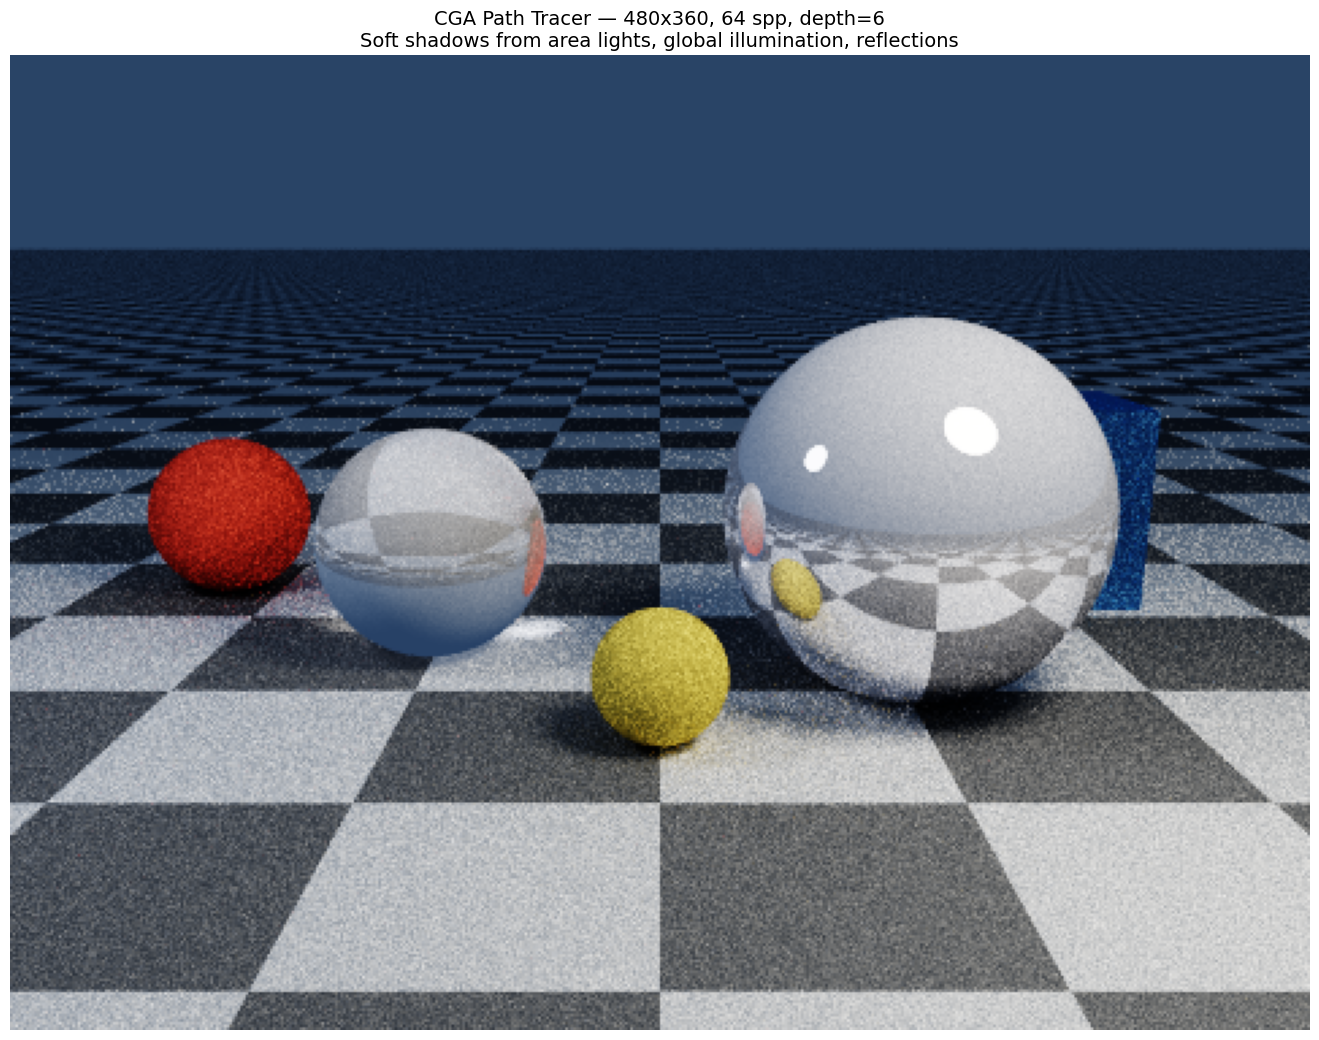

Saved to GA-pathtracing-output.png


In [16]:
# Cell 16 — Higher quality path trace with soft shadows

cam_final = Camera(position=np.array([0., 2.5, -5.]),
                   look_at=np.array([0., 0., 5.]),
                   fov_deg=58, width=480, height=360)

print('Final path trace render at 480x360, 64 spp...')
img_final_pt = render_pt(pt_scene, cam_final, spp=64, max_depth=6)
img_final_tm = tonemap_aces(img_final_pt)

plt.figure(figsize=(14, 10.5))
plt.imshow(img_final_tm)
plt.axis('off')
plt.title('CGA Path Tracer — 480x360, 64 spp, depth=6\n'
          'Soft shadows from area lights, global illumination, reflections',
          fontsize=14)
plt.tight_layout()
plt.show()

# Save
img_pil = Image.fromarray((img_final_tm * 255).astype(np.uint8))
img_pil.save('GA-pathtracing-output.png')
print('Saved to GA-pathtracing-output.png')

## Summary

This notebook extended the CGA ray tracer from Dorst et al. Ch.23 with:

### Path Tracing
- **Monte Carlo integration** of the rendering equation with cosine-weighted hemisphere sampling
- **CGA rotation rotors** to orient hemisphere samples around surface normals
- **Russian Roulette** for unbiased path termination
- **Next Event Estimation** — direct area light sampling at each bounce

### Soft Shadows
- **Area lights** represented as CGA spheres ($\hat{S} = P - \frac{r^2}{2}e_\infty$)
- Random point sampling on light surface produces natural penumbra

### Precomputed Radiance Transfer
- **Spherical Harmonics** basis functions (real, order 0-2, 9 coefficients)
- **Environment map projection** into SH via Monte Carlo
- **Transfer coefficient** precomputation with visibility (shadowed PRT)
- **Real-time relighting** via dot product: $L_o = \text{albedo} \cdot \sum L_{lm} T_{lm}$
- Demonstrated relighting under warm overhead, sunset, and cool blue environments

### CGA Throughout
- All geometric primitives in CGA (points, spheres, planes, lines)
- Transformations via CGA versors (sandwich product)
- Hemisphere sampling oriented with CGA rotation rotors
- Area lights as CGA IPNS spheres